In [1]:
# notebook magics
# inline/notebook/interactive
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!
# os.chdir("./3D")
os.getcwd()

'/home/nb0817/ps-model-exact/3D'

In [2]:
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt
import xp as xp
import matplotlib as mpl

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 100
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 100  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!

import fixed_center_of_mass_exact_3D as fcm

os.chdir("../2D")
import fixed_center_of_mass_exact_2D as fcm2D
from plotting import fromgpu

[xp] backend set to numpy


In [3]:
base_params = {
        'g_1': 1.0, 'g_2': 1.0,
        'M_1': 2e3, 'M_2': 2e3,
        'NR': 41, 'Nr': 41, 'Ng': 42,
        'J': 1, 'potential': 'erf_coulomb',
        'preconditioner': 'naive',
        'verbosity': 0, 't': 64,
        'extent':np.array([0.5,4,10])
    }
args = Namespace(**base_params)
H = fcm.Hamiltonian(args)

Potential: erf_coulomb
extent in unscaled coords: [0.5 4. ] 10.0
extent in   scaled coords: [ 2.81188234 22.49505873] 1.7781682849385496
[Build Vsph from Vgrid] Elapsed time: 6.17e+02us
Preconditioner requires 1MB.
[Build preconditioner naive] Elapsed time: 90.5us


In [4]:
# Ad_vn, Ad_n = H.BO_spectrum()
# print(Ad_n.shape)
# print(Ad_vn.shape)
Ad_vn, U_n, U_v, Ad_n = H._build_preconditioner_BO()

Building U_n
[Build Hel] Elapsed time: 1.03e+07us
[Diag  Hel] Elapsed time: 3.79e+07us
[Phase match U_n] Elapsed time: 1.8e+06us
[Build Hbo] Elapsed time: 8.49e+03us
[Diag  Hbo] Elapsed time: 4.51e+06us
[Phase match U_v] Elapsed time: 2.22e+04us


Ad_vn[0,:4].T =  [[-3.38482592 -3.31140853 -3.25102857 -3.19644796 -3.14335672 -3.09135487
  -3.03529716 -2.99363408]
 [-3.38481126 -3.31139437 -3.25101511 -3.19643441 -3.14334185 -3.09134066
  -3.03528338 -2.99360856]
 [-3.375669   -3.30064573 -3.2373105  -3.18289428 -3.12997116 -3.07965248
  -3.02546462 -2.9786126 ]
 [-3.37565489 -3.30063157 -3.23729712 -3.18288096 -3.12995678 -3.07963801
  -3.02545234 -2.97858619]]
min 6 1.025
<R> =  1.008015147198661
\sqrt{<R^2>} =  1.0113259181605083


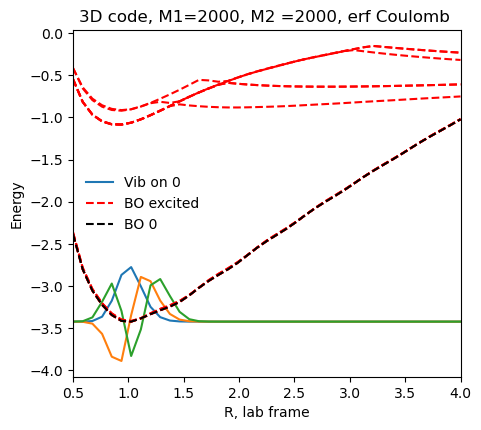

In [5]:
fig,ax = plt.subplots(figsize=(5,4.5))
n=0
print("Ad_vn[0,:4].T = ",Ad_vn[:8,:4].T)
# print("Ad_vn[1,:4].T = ",Ad_vn[1,:4].T)
print("min", np.argmin(Ad_n[:,0]), H.R_lab[np.argmin(Ad_n[:,0])])

ax.plot(H.R_lab, U_v[n,:,0]*1 + np.min(Ad_n[:,n]), label="Vib on 0")
ax.plot(H.R_lab, U_v[n,:,1]*1 + np.min(Ad_n[:,n]))
ax.plot(H.R_lab, U_v[n,:,2]*1 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,3]*2 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,4]*2 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, Ad_n[:,0])
ax.plot(H.R_lab, Ad_n[:,1], c='r', linestyle='--', label="BO excited") 
for j in range(10):
    ax.plot(H.R_lab, Ad_n[:,j], c='r', linestyle='--')
ax.plot(H.R_lab, (Ad_n[:,n]), color='k', label="BO 0", linestyle='--')
ax.set_xlabel("R, lab frame")
ax.set_ylabel("Energy")
ax.set_title("3D code, M1={:.0f}, M2 ={:.0f}, erf Coulomb ".format(args.M_1, args.M_2))
print("<R> = ", np.sum(U_v[0,:,0]*H.R_lab*U_v[0,:,0]))
print(r"\sqrt{<R^2>} = ", np.sqrt(np.sum(U_v[0,:,0]*(H.R_lab**2)*U_v[0,:,0])))
ax.legend(frameon=False)
ax.set_xmargin(0)
# ax.set_ylim(-1.5,1)
# display(fig)
# fig.savefig("erf_2e1.pn3

In [6]:
wfc = U_n[np.argmin(Ad_n[:,0]),:,0]
# wfc = U_n[16,:,0]
print(wfc.shape)
wfc = np.reshape(wfc, (args.Nr, args.Ng, 2*args.J+1))
print(wfc.shape)
print("max", np.max(np.abs(wfc[:,:,:].real)))

(5166,)
(41, 42, 3)
max 0.2494152962646968


In [7]:
from scipy.special import sph_harm_y
j = H.j
Om = H.Om
Nplot = 29

theta = np.linspace(0, np.pi, Nplot, endpoint=True)
phi = np.linspace(0, 2 * np.pi, Nplot+1)

# rotate out of the sph harm basis to sph grid
Yj, Yo, Yt, Yp = np.meshgrid(j,Om,theta,phi)
Yjo = sph_harm_y(Yj,Yo,Yt,Yp)
print(Yjo.shape, wfc.shape)
wfc_sph = np.einsum('ojtp,rjo->rtp', Yjo,wfc)
print(wfc_sph.shape)
print("max", np.max(np.abs(wfc_sph[:,:,0].real)))
print("imag part", np.sum(np.abs(wfc_sph.imag)))

(3, 42, 29, 30) (41, 42, 3)
(41, 29, 30)
max 0.00171493222546441
imag part 721.3755236202674


In [8]:
# fig,ax = plt.subplots()
# im = plt.imshow(wfc_sph[:,:,0].real)
# plt.colorbar(im)
# print("max", np.max(np.abs(wfc_sph[:,:,15].imag)))
# display(fig)

contour levels [-6.71036635 -6.24119471 -5.77202306 -5.30285141 -4.83367977 -4.36450812
 -3.89533647 -3.42616483 -2.95699318 -2.48782154 -2.01864989 -1.54947824
 -1.0803066  -0.61113495 -0.1419633   0.32720834]
wfc limits -0.0011302247936867274 0.0011302247936867274


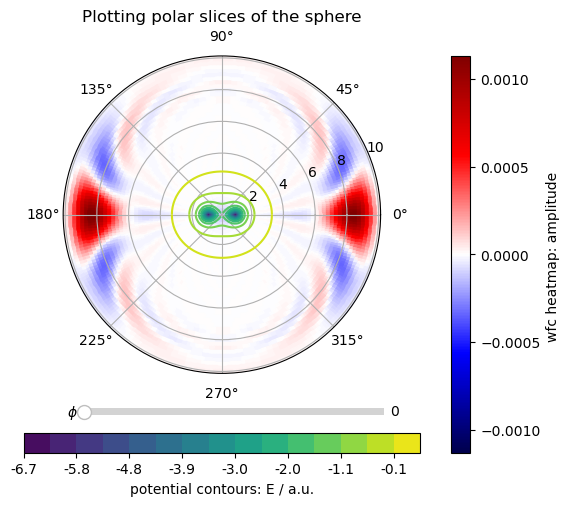

In [9]:
from matplotlib.widgets import Slider
def plot_psi3D_BO(wfc, H, levels=None, Nplot=150, scale='linear'):
    fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(6,5))
    # for the potential plotting
    g     = fromgpu(H.g)
    r_lab = fromgpu(H.r_lab)
    Vgrid = fromgpu(H.Vgrid)

    wfc[:,:,:] /= fromgpu(H.r[:,None,None]) # rescale the radial wfc for 3D

    # rotate out of the sph harm basis to sph grid
    j = fromgpu(H.j)
    Om = fromgpu(H.Om)
    theta = np.linspace(0, np.pi, Nplot, endpoint=True)
    phi = np.linspace(0, 2 * np.pi, Nplot+1)
    Yj, Yo, Yt, Yp = np.meshgrid(j,Om,theta,phi)
    Yjo = sph_harm_y(Yj,Yo,Yt,Yp)
    wfc_sph = np.einsum('ojtp,rjo->rtp', Yjo,wfc)

    # plot potential on grid of (r, gamma)
    if levels is None:
        levels = np.linspace(xp.min(Vgrid[16,:,:]),
                                xp.max(Vgrid[16,:,:]), 16) # 0.15 a.u. ~4 eV range
    print("contour levels", levels)
    ax.contour(*xp.meshgrid(g, r_lab, indexing='ij'), Vgrid[16,:,:].T, levels=levels)
    ax.contour(*xp.meshgrid(g+np.pi, r_lab, indexing='ij'), Vgrid[16,:,:].T, levels=levels)
    cs = ax.contourf(*np.meshgrid(g, r_lab, indexing='ij'), Vgrid[16,:,:].T, levels=levels) # dummy contour with filled patches
    ax.set_title("Plotting polar slices of the sphere")

    
    if scale == 'linear':
        cmap = 'seismic'
        limit = np.max(np.abs(wfc_sph.real))
        # print("lim", limit)
        # limit= 1
        toplimit = limit
        lowlimit = -limit
    elif scale == 'log':
        cmap = 'Blues'
        limit = np.max(np.abs(wfc_sph))
        toplimit = limit
        lowlimit = limit - 6  # 6 orders of magnitude
    else:
        raise RuntimeError(f"scale must be either linear or log, not `{scale}`!")

    print("wfc limits", lowlimit, toplimit)

    if scale=='linear':
        pc1 = ax.pcolormesh(theta, r_lab, wfc_sph[:,:,0].real,
                      cmap=cmap, edgecolor='face',
                      antialiased=True,
                      vmin=lowlimit, vmax=toplimit)#, shading='gouraud')
        pc2 = ax.pcolormesh(-1*theta, r_lab, wfc_sph[:,:,Nplot//2].real,
                      cmap=cmap, edgecolor='face',
                      antialiased=True,
                      vmin=lowlimit, vmax=toplimit)#, shading='gouraud')
        cbar2 = fig.colorbar(pc1, orientation='vertical', fraction=0.1)
        cbar2.set_label("wfc heatmap: amplitude ")
    elif scale=='log':
        pc1 = ax.pcolormesh(theta, r_lab, np.abs(wfc_sph[:,:,0])**2,
                      cmap=cmap, edgecolor='face',
                      antialiased=True,
                      vmin=lowlimit, vmax=toplimit)#, shading='gouraud')
        pc2 = ax.pcolormesh(-1*theta, r_lab, np.abs(wfc_sph[:,:,Nplot//2])**2,
                      cmap=cmap, edgecolor='face',
                      antialiased=True,
                      vmin=lowlimit, vmax=toplimit)#, shading='gouraud')
        cbar2 = fig.colorbar(pc1, orientation='vertical', fraction=0.1)
        cbar2.set_label("wfc heatmap: Log[density] ")
    fig.tight_layout()

    cbar = fig.colorbar(cs, orientation='horizontal', fraction=0.05)
    cs.remove()
    cbar.set_label("potential contours: E / a.u.")
    formatter = mpl.ticker.FormatStrFormatter('%.1f')
    cbar.ax.xaxis.set_major_formatter(formatter)

    ax_phi = plt.axes([0.18, 0.15, 0.5, 0.03])
    slider_phi = Slider(ax_phi,r"$\phi$",0,Nplot//2-1,valstep=1)

    def update_psi(val):
        pc1.remove()
        pc2.remove()
        # if scale=='linear':
        idx_g = int(slider_g.val)
        pc1 = ax.pcolormesh(theta, r_lab, wfc_sph[:,:,0+idx_g].real,
                      cmap=cmap, edgecolor='face',
                      antialiased=True,
                      vmin=lowlimit, vmax=toplimit)
        pc2 = ax.pcolormesh(-1*theta, r_lab, wfc_sph[:,:,Nplot//2+idx_g].real,
                      cmap=cmap, edgecolor='face',
                      antialiased=True,
                      vmin=lowlimit, vmax=toplimit)
        
        slider_phi.valtext.set_text(f"{phi[idx_g]/xp.pi:.3f} π")
        fig.canvas.draw_idle()

    slider_phi.on_changed(update_psi)
    plt.show()
    # display(fig)
    # return mpl.animation.FuncAnimation(fig, animate, frames=Nplot+1)
    # return fig

fig = plot_psi3D_BO(wfc,H, scale="linear")
# display(fig)

In [10]:
H2D = fcm2D.Hamiltonian(args)
Ad_2vn, Ad_2n = H2D.BO_spectrum()

KeyError: 'erf_coulomb'

In [ ]:
from scipy.special import erf
rl = np.linspace(0,3,200)
a = 2
test = -erf(a*rl)/rl

fig,ax = plt.subplots()
ax.plot(rl,test)
display(fig)

In [ ]:
fig,ax = plt.subplots(figsize=(5,4))
argmin = np.argmin(Ad_n[:,0])
offset = Ad_n[argmin,0]-Ad_2n[argmin,0]
print("offset",offset)
ax.plot(H.R_lab, Ad_n[:,0], c='k', label="3D")
ax.plot(H.R_lab, Ad_n[:,1], c='k') 
ax.plot(H.R_lab, Ad_n[:,2], c='k')
ax.plot(H.R_lab, Ad_n[:,3], c='k')
ax.plot(H.R_lab, Ad_n[:,4], c='k')

ax.plot(H.R_lab, Ad_2n[:,0]+offset, linestyle="--", c='r', label="2D")
ax.plot(H.R_lab, Ad_2n[:,1]+offset, linestyle="--", c='r') 
ax.plot(H.R_lab, Ad_2n[:,2]+offset, linestyle="--", c='r')
ax.plot(H.R_lab, Ad_2n[:,3]+offset, linestyle="--", c='r')
ax.plot(H.R_lab, Ad_2n[:,4]+offset, linestyle="--", c='r')
ax.set_title("Comparing BO, offset aligned")
ax.set_xlabel("R_lab")
ax.set_ylabel("E")
ax.set_xmargin(0)
ax.legend(frameon=False)
display(fig)